In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# Importação do dataset
df = pd.read_csv("mecaniqa_dataset.csv")

# Preparação dos dados
df.columns = df.columns.str.strip()

df["Data"] = pd.to_datetime(
    df["Data"],
    format="%Y-%m-%d",
    errors="raise"
)

df = df.set_index("Data")
df = df.sort_index()

df.head()

,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


In [3]:
df.describe()

,Trocas_Oleo,Manutencao_Motor
count,725.000000,728.000000
mean,26.020690,10.179945
std,11.620655,5.419338
min,0.000000,-2.000000
25%,18.000000,7.000000
50%,26.000000,10.000000
75%,33.000000,13.000000
max,150.000000,85.000000


Tratamento de Dados Ausentes


In [4]:
df["Trocas_Oleo"] = df["Trocas_Oleo"].interpolate()
df["Manutencao_Motor"] = df["Manutencao_Motor"].interpolate()

df.isnull().sum()

Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64

Visualização da Série Temporal

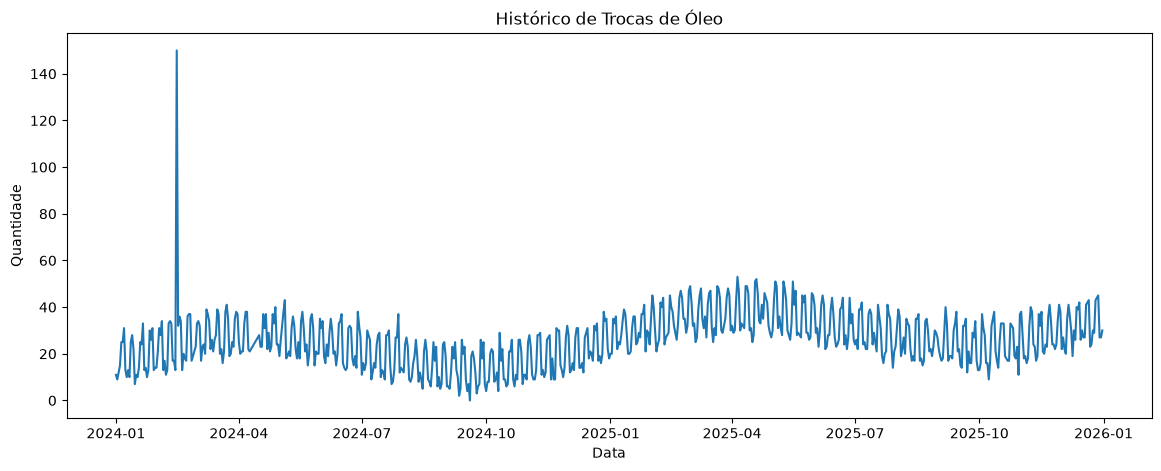

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(df.index, df["Trocas_Oleo"])

plt.title("Histórico de Trocas de Óleo")
plt.xlabel("Data")
plt.ylabel("Quantidade")

plt.show()

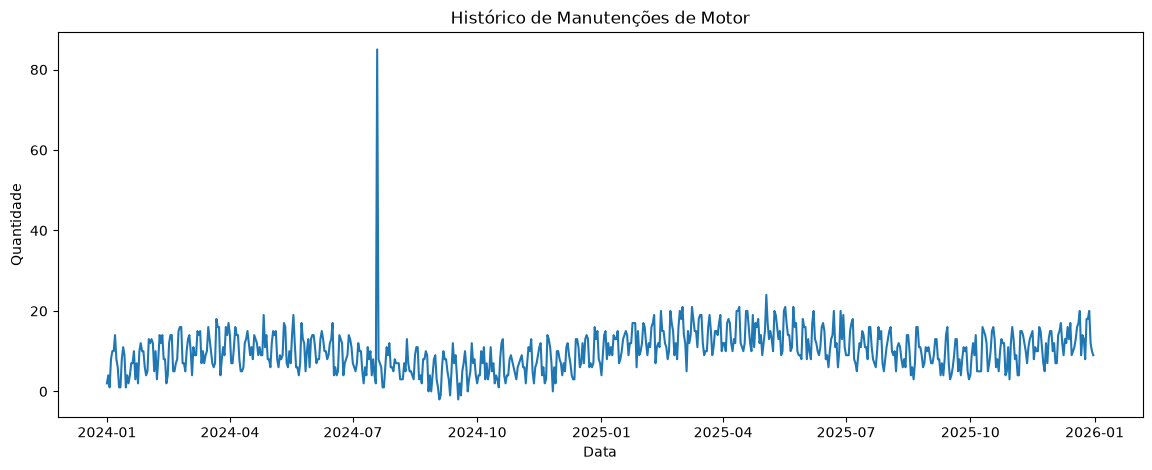

In [6]:
plt.figure(figsize=(14, 5))

plt.plot(df.index, df["Manutencao_Motor"])

plt.title("Histórico de Manutenções de Motor")
plt.xlabel("Data")
plt.ylabel("Quantidade")

plt.show()

Agora vamos normalizar para remover os outliers

In [7]:
# Corrigir valores negativos
df["Manutencao_Motor"] = df["Manutencao_Motor"].clip(lower=0)

# Limitar valores muito altos
df["Trocas_Oleo"] = df["Trocas_Oleo"].clip(upper=55)
df["Manutencao_Motor"] = df["Manutencao_Motor"].clip(upper=26)

E analisar a Média Temporal

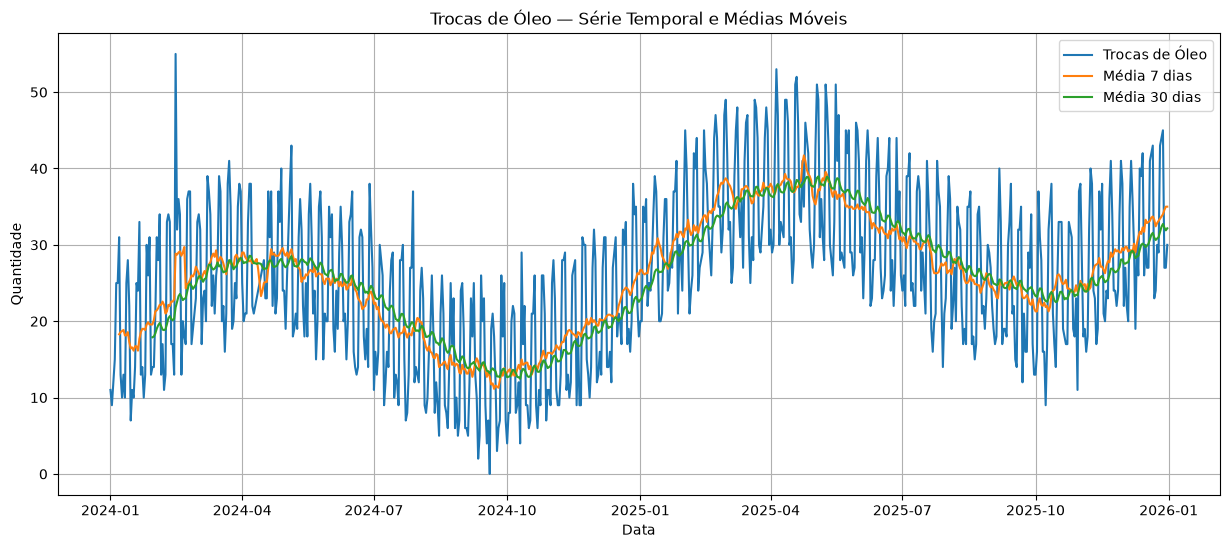

In [8]:
# Trocas de Óleo
df["Media_7_dias_Oleo"] = df["Trocas_Oleo"].rolling(window=7).mean()
df["Media_30_dias_Oleo"] = df["Trocas_Oleo"].rolling(window=30).mean()

# Manutenção de Motor
df["Media_7_dias_Motor"] = df["Manutencao_Motor"].rolling(window=7).mean()
df["Media_30_dias_Motor"] = df["Manutencao_Motor"].rolling(window=30).mean()

plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Trocas_Oleo"],
    label="Trocas de Óleo"
)

plt.plot(
    df.index,
    df["Media_7_dias_Oleo"],
    label="Média 7 dias"
)

plt.plot(
    df.index,
    df["Media_30_dias_Oleo"],
    label="Média 30 dias"
)

plt.title("Trocas de Óleo — Série Temporal e Médias Móveis")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.legend()
plt.grid(True)

plt.show()

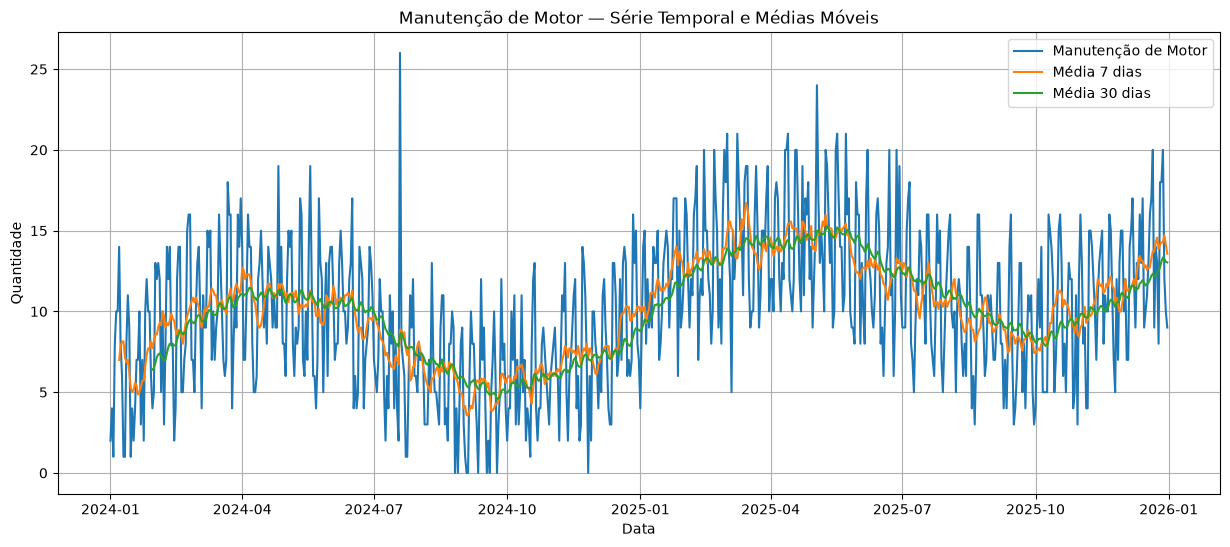

In [9]:
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Manutencao_Motor"],
    label="Manutenção de Motor"
)

plt.plot(
    df.index,
    df["Media_7_dias_Motor"],
    label="Média 7 dias"
)

plt.plot(
    df.index,
    df["Media_30_dias_Motor"],
    label="Média 30 dias"
)

plt.title("Manutenção de Motor — Série Temporal e Médias Móveis")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
# Decisões do brainstorm
modelo_escolhido = "additive"
periodo_escolhido = 7

# Média móvel de sete dias
serie_oleo = df["Trocas_Oleo"]
serie_motor = df["Manutencao_Motor"]
media_movel_7_dias = serie_oleo.rolling(
    window=periodo_escolhido,
    center=True
).mean()

print("\nPrimeiros valores da média móvel:")
display(media_movel_7_dias.dropna().head())


Primeiros valores da média móvel:


Data
2024-01-04    18.285714
2024-01-05    18.571429
2024-01-06    18.714286
2024-01-07    18.857143
2024-01-08    18.142857
Name: Trocas_Oleo, dtype: float64

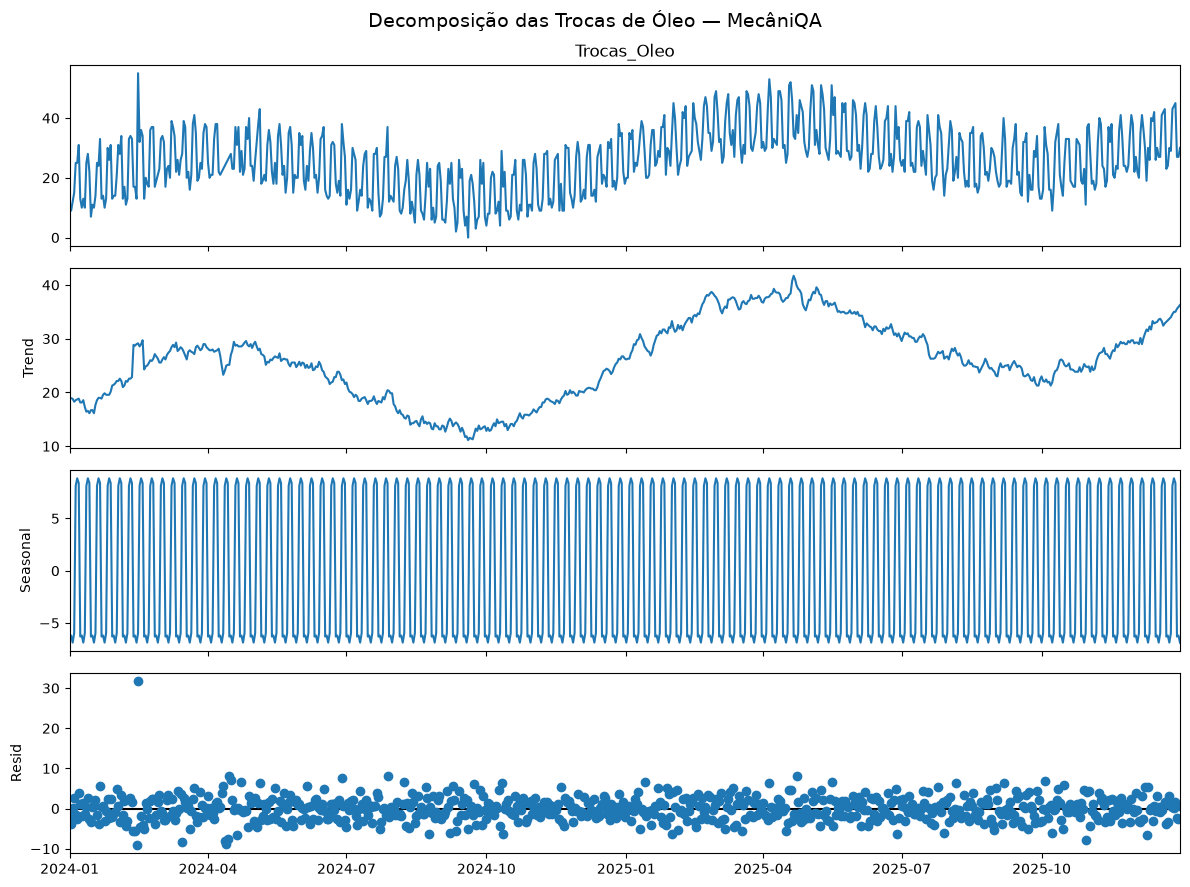

Modelo escolhido: additive
Período escolhido: 7 dias


In [11]:
# Decomposição temporal
resultado = seasonal_decompose(
    serie_oleo,
    model=modelo_escolhido,
    period=periodo_escolhido,
    extrapolate_trend=periodo_escolhido
)

# Gera os quatro gráficos
fig = resultado.plot()

fig.set_size_inches(12, 9)
fig.suptitle(
    "Decomposição das Trocas de Óleo — MecâniQA",
    fontsize=14
)

fig.tight_layout()
plt.show()

print("Modelo escolhido:", modelo_escolhido)
print("Período escolhido:", periodo_escolhido, "dias")

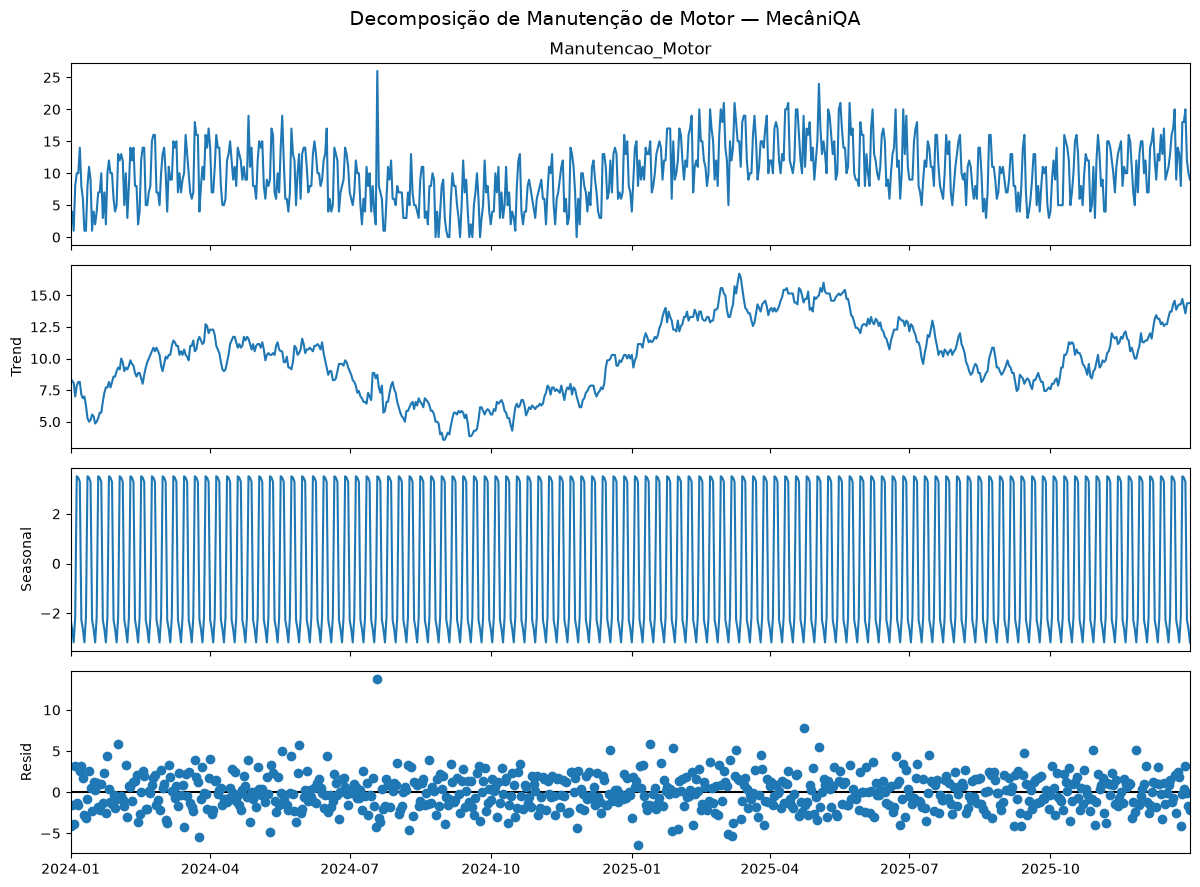

Modelo escolhido: additive
Período escolhido: 7 dias


In [12]:
# Decomposição temporal
resultado = seasonal_decompose(
    serie_motor,
    model=modelo_escolhido,
    period=periodo_escolhido,
    extrapolate_trend=periodo_escolhido
)

# Gera os quatro gráficos
fig = resultado.plot()

fig.set_size_inches(12, 9)
fig.suptitle(
    "Decomposição de Manutenção de Motor — MecâniQA",
    fontsize=14
)

fig.tight_layout()
plt.show()

print("Modelo escolhido:", modelo_escolhido)
print("Período escolhido:", periodo_escolhido, "dias")

Modelos

In [13]:
def modelo_naive(serie):
    return serie.shift(1)

def modelo_media_movel(serie, janela):
    return serie.shift(1).rolling(window=janela).mean()

df["Previsao_Naive_Oleo"] = modelo_naive(df["Trocas_Oleo"])

df["Previsao_Media_7_Oleo"] = modelo_media_movel(
    df["Trocas_Oleo"],
    janela=7
)

df["Previsao_Media_30_Oleo"] = modelo_media_movel(
    df["Trocas_Oleo"],
    janela=30
)

df["Previsao_Naive_Motor"] = modelo_naive(df["Manutencao_Motor"])

df["Previsao_Media_7_Motor"] = modelo_media_movel(
    df["Manutencao_Motor"],
    janela=7
)

df["Previsao_Media_30_Motor"] = modelo_media_movel(
    df["Manutencao_Motor"],
    janela=30
)

In [14]:
display(
    df[
        [
            "Trocas_Oleo",
            "Previsao_Naive_Oleo",
            "Previsao_Media_7_Oleo",
            "Previsao_Media_30_Oleo"
        ]
    ].tail(10)
)

,Trocas_Oleo,Previsao_Naive_Oleo,Previsao_Media_7_Oleo,Previsao_Media_30_Oleo
Data,,,,
2025-12-22,23.0,43.0,33.714286,31.566667
2025-12-23,24.0,23.0,33.285714,30.966667
2025-12-24,30.0,24.0,32.428571,30.633333
2025-12-25,29.0,30.0,32.857143,30.833333
2025-12-26,43.0,29.0,33.142857,31.000000
2025-12-27,44.0,43.0,33.428571,31.700000
2025-12-28,45.0,44.0,33.714286,32.366667
2025-12-29,27.0,45.0,34.000000,32.733333
2025-12-30,27.0,27.0,34.571429,32.266667


GRÁFICOS


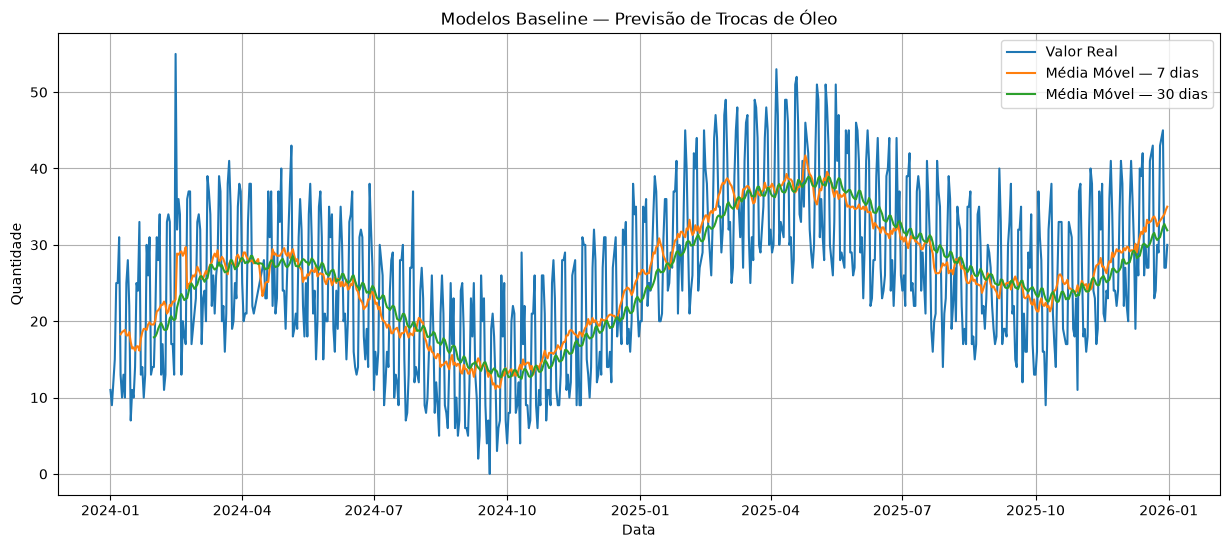

In [15]:
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Trocas_Oleo"],
    label="Valor Real"
)

plt.plot(
    df.index,
    df["Previsao_Media_7_Oleo"],
    label="Média Móvel — 7 dias"
)

plt.plot(
    df.index,
    df["Previsao_Media_30_Oleo"],
    label="Média Móvel — 30 dias"
)

plt.title("Modelos Baseline — Previsão de Trocas de Óleo")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.legend()
plt.grid(True)
plt.show()

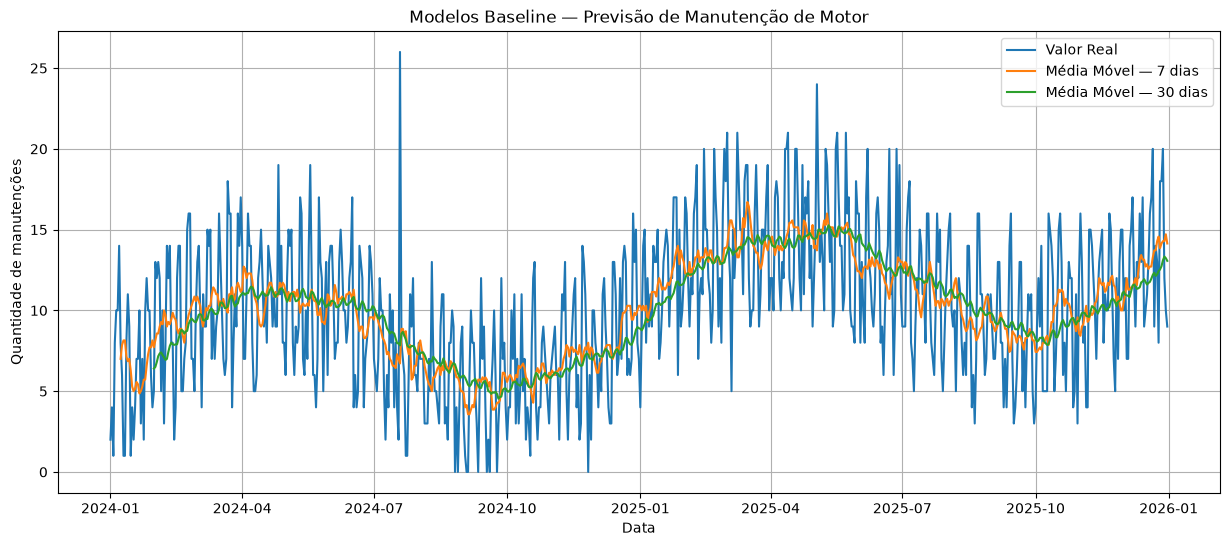

In [16]:

plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Manutencao_Motor"],
    label="Valor Real"
)

plt.plot(
    df.index,
    df["Previsao_Media_7_Motor"],
    label="Média Móvel — 7 dias"
)

plt.plot(
    df.index,
    df["Previsao_Media_30_Motor"],
    label="Média Móvel — 30 dias"
)

plt.title("Modelos Baseline — Previsão de Manutenção de Motor")
plt.xlabel("Data")
plt.ylabel("Quantidade de manutenções")
plt.legend()
plt.grid(True)
plt.show()

# Importar o TimeSeriesSplit do scikit-learn e criar os recortes do dataset respeitando a linha cronológica.

In [17]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# Criar um bloco avaliador que importe e calcule as métricas MAE, RMSE e MAPE.
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

erros_mae  = []
erros_rmse = []
erros_mape = []

for treino, teste in tscv.split(df):
    dados_teste = df.iloc[teste]

    real = dados_teste["Trocas_Oleo"]
    previsao = dados_teste["Previsao_Media_7_Oleo"]

    dados_validos = real != 0
    real_mape = real[dados_validos]
    previsao_mape = previsao[dados_validos]

    erros_mae.append(mean_absolute_error(real, previsao))
    erros_rmse.append(np.sqrt(mean_squared_error(real, previsao)))
    erros_mape.append(mean_absolute_percentage_error(real_mape, previsao_mape) * 100)

mae = np.mean(erros_mae)
rmse = np.mean(erros_rmse)
mape = np.mean(erros_mape)

# O output final da célula de código deve imprimir abertamente: 
# "Resultados do Baseline - MAE: X, RMSE: Y, MAPE: Z%". 

print('-Médias Móveis-')
print(f'Resultados do Baseline - MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}')


-Médias Móveis-
Resultados do Baseline - MAE: 7.36, RMSE: 8.09, MAPE: 37.22


In [18]:
erros_mae  = []
erros_rmse = []
erros_mape = []

for treino, teste in tscv.split(df):
    dados_teste = df.iloc[teste]

    real = dados_teste["Trocas_Oleo"]
    previsao = dados_teste["Previsao_Naive_Oleo"]

    dados_validos = real != 0
    real_mape = real[dados_validos]
    previsao_mape = previsao[dados_validos]

    erros_mae.append(mean_absolute_error(real, previsao))
    erros_rmse.append(np.sqrt(mean_squared_error(real, previsao)))
    erros_mape.append(mean_absolute_percentage_error(real_mape, previsao_mape) * 100)

mae = np.mean(erros_mae)
rmse = np.mean(erros_rmse)
mape = np.mean(erros_mape)

# O output final da célula de código deve imprimir abertamente: 
# "Resultados do Baseline - MAE: X, RMSE: Y, MAPE: Z%". 

print('-Naive-')
print(f'Resultados do Baseline - MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}')

# cria cópia do dataset para adicionar as novas features temporais
df_features = df.copy()

# cria lags para trazer informações de dias anteriores
df_features["lag_1_oleo"] = df_features["Trocas_Oleo"].shift(1)
df_features["lag_7_oleo"] = df_features["Trocas_Oleo"].shift(7)
df_features["lag_30_oleo"] = df_features["Trocas_Oleo"].shift(30)

# cria média móvel de 7 dias sem usar informação futura
df_features["rolling_7_oleo"] = df_features["Trocas_Oleo"].shift(1).rolling(window=7).mean()

# trata dados ausentes gerados pelos lags e pela janela rolante
df_features = df_features.dropna()

# valida se as features temporais ficaram alinhadas corretamente
df_features.head(15)

-Naive-
Resultados do Baseline - MAE: 6.65, RMSE: 8.92, MAPE: 32.64


,Trocas_Oleo,Manutencao_Motor,Media_7_dias_Oleo,Media_30_dias_Oleo,Media_7_dias_Motor,Media_30_dias_Motor,Previsao_Naive_Oleo,Previsao_Media_7_Oleo,Previsao_Media_30_Oleo,Previsao_Naive_Motor,Previsao_Media_7_Motor,Previsao_Media_30_Motor,lag_1_oleo,lag_7_oleo,lag_30_oleo,rolling_7_oleo
Data,,,,,,,,,,,,,,,,
2024-01-31,14.0,5.0,20.142857,18.000000,8.142857,6.500000,14.0,19.571429,17.900000,4.0,7.714286,6.400000,14.0,10.0,11.0,19.571429
2024-02-01,21.0,13.0,21.285714,18.400000,8.571429,6.800000,14.0,20.142857,18.000000,5.0,8.142857,6.500000,14.0,13.0,9.0,20.142857
2024-02-02,31.0,12.0,21.428571,19.033333,8.571429,7.166667,21.0,21.285714,18.400000,13.0,8.571429,6.800000,21.0,30.0,12.0,21.285714
2024-02-03,28.0,13.0,21.714286,19.466667,9.000000,7.333333,31.0,21.428571,19.033333,12.0,8.571429,7.166667,31.0,26.0,15.0,21.428571
2024-02-04,34.0,12.0,22.142857,19.766667,9.285714,7.400000,28.0,21.714286,19.466667,13.0,9.000000,7.333333,28.0,31.0,25.0,21.714286
2024-02-05,13.0,5.0,22.142857,19.366667,9.142857,7.233333,34.0,22.142857,19.766667,12.0,9.285714,7.400000,34.0,13.0,25.0,22.142857
2024-02-06,17.0,10.0,22.571429,18.900000,10.000000,7.100000,13.0,22.142857,19.366667,5.0,9.142857,7.233333,13.0,14.0,31.0,22.142857
2024-02-07,11.0,3.0,22.142857,18.833333,9.714286,6.933333,17.0,22.571429,18.900000,10.0,10.000000,7.100000,17.0,14.0,13.0,22.571429
2024-02-08,13.0,8.0,21.000000,18.933333,9.000000,7.000000,11.0,22.142857,18.833333,3.0,9.714286,6.933333,11.0,21.0,10.0,22.142857
